In [1]:
!pip install tensorflow
!pip install optuna
!pip install scikit-learn
!pip install split-folders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 33.3 MB/s eta 0:00:00


In [2]:
!rm -rf ./brain_tumor_dataset
!unzip ./raw-datasets.zip
!rm -rf ./__MACOSX/
!rm -rf ./no
!rm -rf ./yes

Archive:  ./raw-datasets.zip
  inflating: brain_tumor_dataset/no/1 no.jpeg  
  inflating: brain_tumor_dataset/no/10 no.jpg  
  inflating: brain_tumor_dataset/no/11 no.jpg  
  inflating: brain_tumor_dataset/no/12 no.jpg  
  inflating: brain_tumor_dataset/no/13 no.jpg  
  inflating: brain_tumor_dataset/no/14 no.jpg  
  inflating: brain_tumor_dataset/no/15 no.jpg  
  inflating: brain_tumor_dataset/no/17 no.jpg  
  inflating: brain_tumor_dataset/no/18 no.jpg  
  inflating: brain_tumor_dataset/no/19 no.jpg  
  inflating: brain_tumor_dataset/no/2 no.jpeg  
  inflating: brain_tumor_dataset/no/20 no.jpg  
  inflating: brain_tumor_dataset/no/21 no.jpg  
  inflating: brain_tumor_dataset/no/22 no.jpg  
  inflating: brain_tumor_dataset/no/23 no.jpg  
  inflating: brain_tumor_dataset/no/24 no.jpg  
  inflating: brain_tumor_dataset/no/25 no.jpg  
  inflating: brain_tumor_dataset/no/26 no.jpg  
  inflating: brain_tumor_dataset/no/27 no.jpg  
  inflating: brain_tumor_dataset/no/28 no.jpg  
  inflating

In [3]:
!rm -rf ./dataset

import splitfolders

input_folder = "brain_tumor_dataset"
output_folder = "dataset"

splitfolders.ratio(
  input=input_folder,
  output=output_folder,
  seed=32,
  ratio=(0.7, 0.2, 0.1)
)

Copying files: 253 files [00:00, 5076.20 files/s]


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import f1_score, roc_auc_score, recall_score, accuracy_score

import optuna
import numpy as np

In [5]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TF Version:", tf.__version__)
gpu = tf.config.list_physical_devices('GPU')
print(f"GPU Name: {tf.test.gpu_device_name()}")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF Version: 2.20.0
GPU Name: /device:GPU:0


In [6]:
# ============================================
# CONFIGURATION
# ===========================================

IMG_HEIGHT = 228
IMG_WIDTH = 228
BATCH_SIZE=8

In [7]:
def data_augmentation():
  # ============================================
  # IMAGE DATA GENERATOR
  # ===========================================

  train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    preprocessing_function=vgg_preprocess,
  )

  validation_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=vgg_preprocess,
  )

  # ============================================
  # LOAD IMAGE
  # ===========================================

  train_dir = "dataset/train"
  validation_dir = "dataset/val"
  test_dir = "dataset/test"

  train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
  )

  validation_data = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary' ,
    shuffle=False,
  )

  test_data = validation_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
  )
  print(train_data.class_indices)
  return train_data, validation_data, test_data


In [8]:
# ============================================
# OPTUNA OPTIMATION
# ===========================================

def objective(trial: optuna.Trial):
  trainable = trial.suggest_categorical('trainable', [True, False])
  layers_trainable = trial.suggest_int('layers_trainable', 10, 30, step=5)
  dropout_rate = trial.suggest_float('droprate', 0.25, 0.5, step=0.05)
  n_dense = trial.suggest_int('n_dense', 1, 3)
  lr = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)

  base_model = VGG16(
      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
      include_top=False,
      weights='imagenet',
      pooling=None,
  )

  base_model.trainable = trainable
  if trainable:
    for layer in base_model.layers[:-layers_trainable]:
      layer.trainable = False
    for layer in base_model.layers[-layers_trainable:]:
      layer.trainable = True

  input = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
  x = base_model(input, training=False)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.BatchNormalization()(x)
  x = layers.Dropout(dropout_rate)(x)

  for i in range(n_dense):
    dense_unit = trial.suggest_categorical(f'dense_unit_{i}', [128, 256, 512])
    dense_dropout = trial.suggest_float(f'dense_droprate_{i}', 0.1, 0.4, step=0.05)
    x = layers.Dense(dense_unit, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dense_dropout)(x)

  output = layers.Dense(1, activation='sigmoid')(x)
  model = models.Model(input, output)

  model_opt = optimizers.Adam(learning_rate=lr)
  model.compile(
    optimizer=model_opt,
    loss='binary_crossentropy',
    metrics=[
      'accuracy',
      tf.keras.metrics.Recall(name='recall'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.AUC(name='auc')
    ]
  )

  callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
  ]

  train_data, validation_data, test_data = data_augmentation()
  model.fit(
    train_data,
    validation_data=validation_data,
    epochs=100,
    callbacks=callbacks,
    verbose=0,
    batch_size=BATCH_SIZE,
  )

  # recall and auc for scoring
  validation_data.reset()
  y_prob = model.predict(validation_data).flatten()
  y_pred = (y_prob > 0.5).astype(int)
  y_true = validation_data.classes

  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  auc = roc_auc_score(y_true, y_prob)
  accuracy = accuracy_score(y_true, y_pred)

  trial.set_user_attr('recall', recall)
  trial.set_user_attr('auc', auc)
  trial.set_user_attr('f1', f1)
  trial.set_user_attr('accuracy', accuracy)

  print("===============TRIAL======================")
  print(f"Trial Recall       : {recall}")
  print(f"Trial AUC          : {auc}")
  print(f"Trial F1           : {f1}")
  print(f"Trial Accuracy     : {accuracy}")

  scoring = 0.5 * recall + 0.5 * auc
  return scoring


In [9]:
# =========================================================
# CREATE OPTUNA STUDY
# =========================================================

study = optuna.create_study(direction='maximize', study_name='model-tunning')
study.optimize(objective,n_trials=20)
best_trial = study.best_trial
print("\n================ FINAL =====================")
print(f"Best Score        : {best_trial.value:.4f}")
print(f"Best AUC          : {best_trial.user_attrs['auc']:.4f}")
print(f"Best Recall       : {best_trial.user_attrs['recall']:.4f}")
print(f"Best F1           : {best_trial.user_attrs['f1']:.4f}")
print(f"Best Accuracy     : {best_trial.user_attrs['accuracy']:.4f}")
print(f"Best Params       : {best_trial.params}")

[I 2026-05-21 12:31:05,401] A new study created in memory with name: model-tunning


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
{'no': 0, 'yes': 1}
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step


[I 2026-05-21 12:33:42,046] Trial 0 finished with value: 0.965195246179966 and parameters: {'trainable': True, 'layers_trainable': 15, 'droprate': 0.25, 'n_dense': 1, 'learning_rate': 1.1428649514572253e-05, 'dense_unit_0': 128, 'dense_droprate_0': 0.30000000000000004}. Best is trial 0 with value: 0.965195246179966.


===============TRIAL======================
Trial Recall       : 0.9354838709677419
Trial AUC          : 0.9949066213921901
Trial F1           : 0.9666666666666667
Trial Accuracy     : 0.96
Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
{'no': 0, 'yes': 1}
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step


[I 2026-05-21 12:36:07,343] Trial 1 finished with value: 0.9575551782682513 and parameters: {'trainable': True, 'layers_trainable': 30, 'droprate': 0.45, 'n_dense': 1, 'learning_rate': 0.0004002819542246613, 'dense_unit_0': 128, 'dense_droprate_0': 0.35}. Best is trial 0 with value: 0.965195246179966.


...

===============TRIAL======================
Trial Recall       : 0.41935483870967744
Trial AUC          : 0.7860780984719864
Trial F1           : 0.5652173913043478
Trial Accuracy     : 0.6
Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
{'no': 0, 'yes': 1}
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step


[I 2026-05-21 13:10:23,126] Trial 18 finished with value: 0.9575551782682512 and parameters: {'trainable': True, 'layers_trainable': 10, 'droprate': 0.25, 'n_dense': 1, 'learning_rate': 0.00021238292824569765, 'dense_unit_0': 256, 'dense_droprate_0': 0.4}. Best is trial 4 with value: 0.9881154499151104.


===============TRIAL======================
Trial Recall       : 1.0
Trial AUC          : 0.9151103565365025
Trial F1           : 0.7654320987654321
Trial Accuracy     : 0.62
Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
{'no': 0, 'yes': 1}
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step


[I 2026-05-21 13:11:44,363] Trial 19 finished with value: 0.9685908319185059 and parameters: {'trainable': False, 'layers_trainable': 15, 'droprate': 0.35, 'n_dense': 2, 'learning_rate': 0.0009364423511659668, 'dense_unit_0': 512, 'dense_droprate_0': 0.2, 'dense_unit_1': 256, 'dense_droprate_1': 0.1}. Best is trial 4 with value: 0.9881154499151104.


===============TRIAL======================
Trial Recall       : 1.0
Trial AUC          : 0.9371816638370118
Trial F1           : 0.8266666666666667
Trial Accuracy     : 0.74

================ FINAL =====================
Best Score        : 0.9881
Best AUC          : 0.9762
Best Recall       : 1.0000
Best F1           : 0.9688
Best Accuracy     : 0.9600
Best Params       : {'trainable': False, 'layers_trainable': 30, 'droprate': 0.3, 'n_dense': 1, 'learning_rate': 0.00025404988066542075, 'dense_unit_0': 256, 'dense_droprate_0': 0.25}


In [10]:
# =========================================================
# TRAIN FINAL MODEL AFTER OPTUNA OPTIMAZTION TUNING
# WITH BEST SCORING
# =========================================================
params = best_trial.params
trainable = params['trainable']
layers_trainable = params['layers_trainable']
dropout_rate = params['droprate']
n_dense = params['n_dense']
lr = params['learning_rate']

base_model_best_trial = VGG16(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet',
    pooling=None,
)

base_model_best_trial.trainable = trainable
if trainable:
  for layer in base_model_best_trial.layers[:-layers_trainable]:
    layer.trainable = False
  for layer in base_model_best_trial.layers[-layers_trainable:]:
    layer.trainable = True

input_best_trial = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x_best_trial = base_model_best_trial(input_best_trial, training=False)
x_best_trial = layers.GlobalAveragePooling2D()(x_best_trial)
x_best_trial = layers.BatchNormalization()(x_best_trial)
x_best_trial = layers.Dropout(dropout_rate)(x_best_trial)

for i in range(n_dense):
  dense_unit = params[f'dense_unit_{i}']
  dense_dropout = params[f'dense_droprate_{i}']
  x_best_trial = layers.Dense(dense_unit, activation='relu')(x_best_trial)
  x_best_trial = layers.BatchNormalization()(x_best_trial)
  x_best_trial = layers.Dropout(dense_dropout)(x_best_trial)

output_best_trial = layers.Dense(1, activation='sigmoid')(x_best_trial)
model_best_trial = models.Model(input_best_trial, output_best_trial)

model_opt = optimizers.Adam(learning_rate=lr)
model_best_trial.compile(
  optimizer=model_opt,
  loss='binary_crossentropy',
  metrics=[
    'accuracy',
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.AUC(name='auc')
  ]
)

model_best_trial.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_41 (InputLayer)     │ (None, 228, 228, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_20     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,345 (56.65 MB)

 Trainable params: 133,121 (520.00 KB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [12]:
# =========================================================
# MODEL FIT WITH BEST PARAM
# =========================================================

callbacks = [
  tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
  tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
]

train_data, validation_data, test_data = data_augmentation()
history_best_trial = model_best_trial.fit(
  train_data,
  validation_data=validation_data,
  epochs=100,
  callbacks=callbacks,
  verbose=1,
  batch_size=BATCH_SIZE,
)

# f1 score validation data
validation_data.reset()
y_prob = model_best_trial.predict(validation_data).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = validation_data.classes

recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MODEL =====================")
print(f"Model Recall       : {recall}")
print(f"Model AUC          : {auc}")
print(f"Model F1           : {f1}")
print(f"Model Accuracy     : {accuracy}")

Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
{'no': 0, 'yes': 1}
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.7330 - auc: 0.8469 - loss: 0.4868 - precision: 0.8144 - recall: 0.7315 - val_accuracy: 0.8000 - val_auc: 0.9703 - val_loss: 0.5575 - val_precision: 1.0000 - val_recall: 0.6774 - learning_rate: 2.5405e-04
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.7500 - auc: 0.8281 - loss: 0.5480 - precision: 0.8265 - recall: 0.7500 - val_accuracy: 0.7800 - val_auc: 0.9703 - val_loss: 0.5523 - val_precision: 1.0000 - val_recall: 0.6452 - learning_rate: 2.5405e-04
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.8182 - auc: 0.8841 - loss: 0.4345 - precision: 0.8958 - recall: 0.7963 - val_accuracy: 0.7600 - val_auc: 0.9677 - val_loss: 0.5267 - val_precision: 0.9524 - val_recall: 0.6452 - learning_rate: 2.5405e-04
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 143m

In [13]:
loss, accuracy, auc, precision, recall = model_best_trial.evaluate(
  test_data,
  verbose=1
)
print(f"\nTest Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
print(f"Test Loss: {loss}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9259 - auc: 0.9943 - loss: 0.3271 - precision: 1.0000 - recall: 0.8750

Test Accuracy: 0.9259259104728699
Test Precision: 1.0
Test Recall: 0.9943181276321411
Test AUC: 0.875
Test Loss: 0.32707998156547546


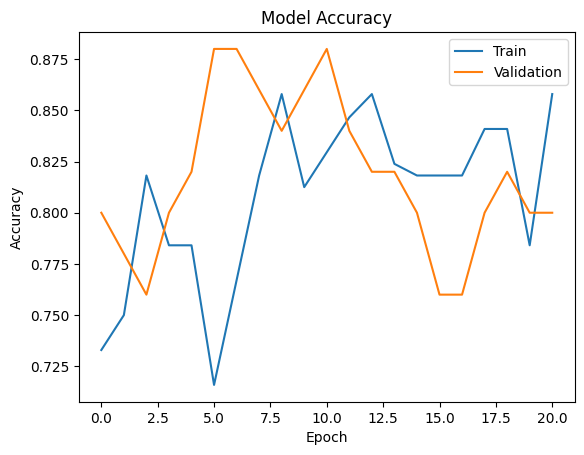

In [14]:
import matplotlib.pyplot as plt

# =========================================================
# VISUALIZATION ACCURACY
# =========================================================

plt.plot(history_best_trial.history['accuracy'])
plt.plot(history_best_trial.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

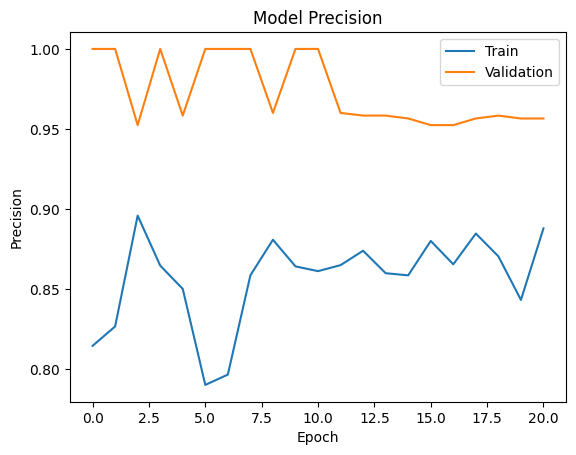

In [15]:
# =========================================================
# VISUALIZATION PRECISION
# =========================================================

plt.plot(history_best_trial.history['precision'])
plt.plot(history_best_trial.history['val_precision'])
plt.title('Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend(['Train', 'Validation'])
plt.show()

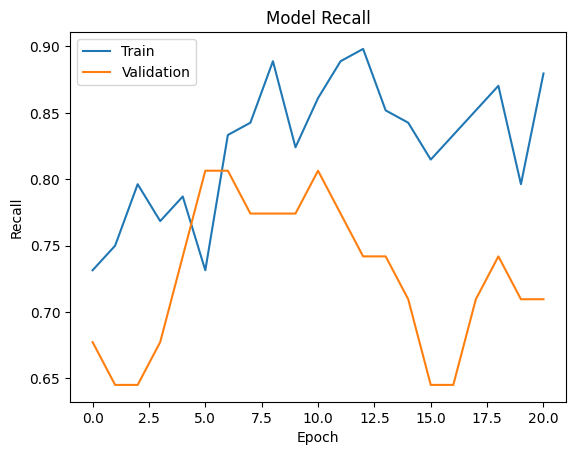

In [16]:
# =========================================================
# VISUALIZATION RECALL
# =========================================================

plt.plot(history_best_trial.history['recall'])
plt.plot(history_best_trial.history['val_recall'])
plt.title('Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend(['Train', 'Validation'])
plt.show()

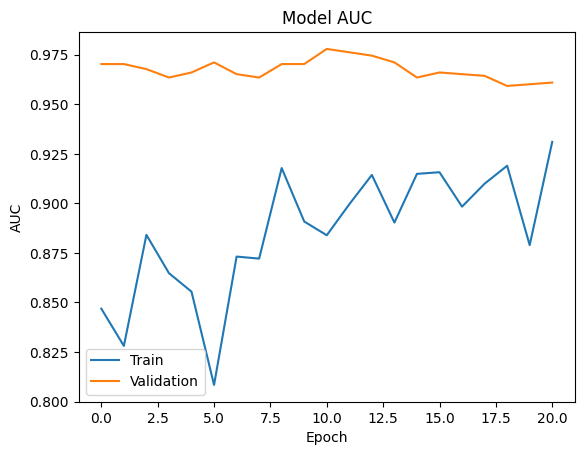

In [17]:
# =========================================================
# VISUALIZATION AUC
# =========================================================

plt.plot(history_best_trial.history['auc'])
plt.plot(history_best_trial.history['val_auc'])
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend(['Train', 'Validation'])
plt.show()

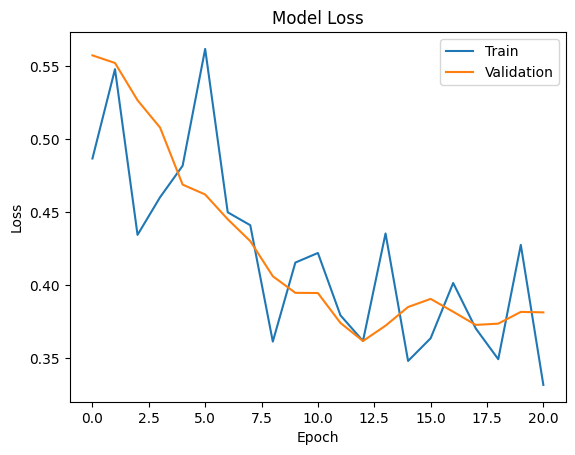

In [18]:
# =========================================================
# VISUALIZATION LOSS
# =========================================================

plt.plot(history_best_trial.history['loss'])
plt.plot(history_best_trial.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [19]:
# =========================================================
# TEST SAMPLE
# =========================================================

image_path = "sample-no.jpg"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model_best_trial.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Prediction Probability:
[[0.36210385]]

Predicted Class:
no


In [20]:
image_path = "sample-yes.jpg"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model_best_trial.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Prediction Probability:
[[0.81297237]]

Predicted Class:
yes


In [22]:
# =========================================================
# TRAIN FINAL MODEL AFTER OPTUNA OPTIMAZTION TUNING
# WITH STABLE TRIAL METRIC
# =========================================================
params = study.trials[0].params # change to trial-n that stable metric
print("Params ==> ", params)
trainable = params['trainable']
layers_trainable = params['layers_trainable']
dropout_rate = params['droprate']
n_dense = params['n_dense']
lr = params['learning_rate']

base_model_stable_trial = VGG16(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet',
    pooling=None,
)

base_model_stable_trial.trainable = trainable
if trainable:
  for layer in base_model_stable_trial.layers[:-layers_trainable]:
    layer.trainable = False
  for layer in base_model_stable_trial.layers[-layers_trainable:]:
    layer.trainable = True

input_stable_trial = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x_stable_trial = base_model_stable_trial(input_stable_trial, training=False)
x_stable_trial = layers.GlobalAveragePooling2D()(x_stable_trial)
x_stable_trial = layers.BatchNormalization()(x_stable_trial)
x_stable_trial = layers.Dropout(dropout_rate)(x_stable_trial)

for i in range(n_dense):
  dense_unit = params[f'dense_unit_{i}']
  dense_dropout = params[f'dense_droprate_{i}']
  x_stable_trial = layers.Dense(dense_unit, activation='relu')(x_stable_trial)
  x_stable_trial = layers.BatchNormalization()(x_stable_trial)
  x_stable_trial = layers.Dropout(dense_dropout)(x_stable_trial)

output_stable_trial = layers.Dense(1, activation='sigmoid')(x_stable_trial)
model_stable_trial = models.Model(input_stable_trial, output_stable_trial)

model_opt = optimizers.Adam(learning_rate=lr)
model_stable_trial.compile(
  optimizer=model_opt,
  loss='binary_crossentropy',
  metrics=[
    'accuracy',
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.AUC(name='auc')
  ]
)

model_stable_trial.summary()

Params ==>  {'trainable': True, 'layers_trainable': 15, 'droprate': 0.25, 'n_dense': 1, 'learning_rate': 1.1428649514572253e-05, 'dense_unit_0': 128, 'dense_droprate_0': 0.30000000000000004}


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_45 (InputLayer)     │ (None, 228, 228, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_22     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,783,041 (56.39 MB)

 Trainable params: 14,743,041 (56.24 MB)

 Non-trainable params: 40,000 (156.25 KB)

In [23]:
# =========================================================
# MODEL FIT WITH STABLE METRIC TRIAL
# =========================================================

callbacks = [
  tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
  tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
]

train_data, validation_data, test_data = data_augmentation()
history_stable_trial = model_stable_trial.fit(
  train_data,
  validation_data=validation_data,
  epochs=100,
  callbacks=callbacks,
  verbose=1,
  batch_size=BATCH_SIZE,
)

validation_data.reset()
y_prob = model_stable_trial.predict(validation_data).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = validation_data.classes

recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MODEL =====================")
print(f"Model Recall       : {recall}")
print(f"Model AUC          : {auc}")
print(f"Model F1           : {f1}")
print(f"Model Accuracy     : {accuracy}")

Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
{'no': 0, 'yes': 1}
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 389ms/step - accuracy: 0.5057 - auc: 0.4847 - loss: 0.9570 - precision: 0.6296 - recall: 0.4722 - val_accuracy: 0.6200 - val_auc: 0.3455 - val_loss: 0.7110 - val_precision: 0.6200 - val_recall: 1.0000 - learning_rate: 1.1429e-05
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.6534 - auc: 0.6567 - loss: 0.8061 - precision: 0.7975 - recall: 0.5833 - val_accuracy: 0.6200 - val_auc: 0.5611 - val_loss: 0.6655 - val_precision: 0.6200 - val_recall: 1.0000 - learning_rate: 1.1429e-05
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 245ms/step - accuracy: 0.6420 - auc: 0.7041 - loss: 0.7327 - precision: 0.7473 - recall: 0.6296 - val_accuracy: 0.6200 - val_auc: 0.7301 - val_loss: 0.6410 - val_precision: 0.6200 - val_recall: 1.0000 - learning_rate: 1.1429e-05
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 234

In [24]:
loss, accuracy, auc, precision, recall = model_stable_trial.evaluate(
  test_data,
  verbose=1
)
print(f"\nTest Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
print(f"Test Loss: {loss}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - accuracy: 0.9259 - auc: 0.9886 - loss: 0.2380 - precision: 1.0000 - recall: 0.8750

Test Accuracy: 0.9259259104728699
Test Precision: 1.0
Test Recall: 0.988636314868927
Test AUC: 0.875
Test Loss: 0.238040953874588


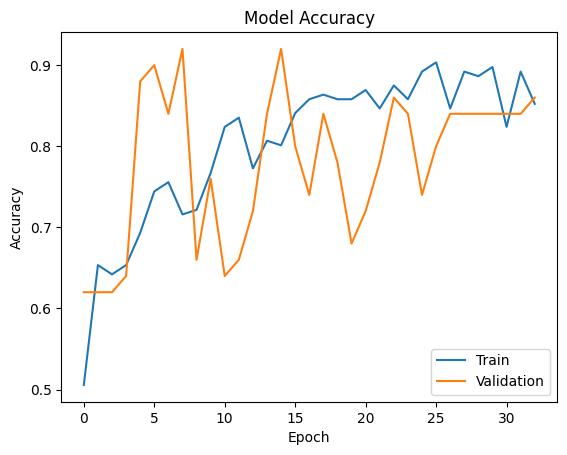

In [25]:
# =========================================================
# VISUALIZATION ACCURACY
# =========================================================

plt.plot(history_stable_trial.history['accuracy'])
plt.plot(history_stable_trial.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

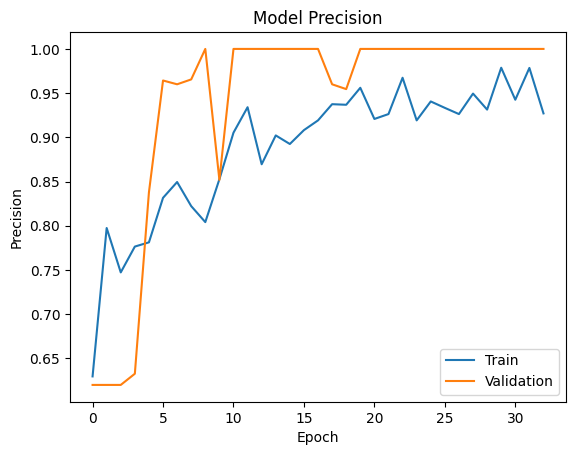

In [26]:
# =========================================================
# VISUALIZATION PRECISION
# =========================================================

plt.plot(history_stable_trial.history['precision'])
plt.plot(history_stable_trial.history['val_precision'])
plt.title('Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend(['Train', 'Validation'])
plt.show()

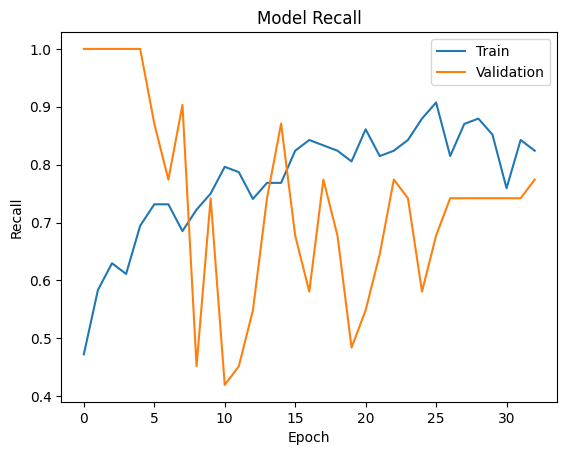

In [27]:
# =========================================================
# VISUALIZATION RECALL
# =========================================================

plt.plot(history_stable_trial.history['recall'])
plt.plot(history_stable_trial.history['val_recall'])
plt.title('Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend(['Train', 'Validation'])
plt.show()

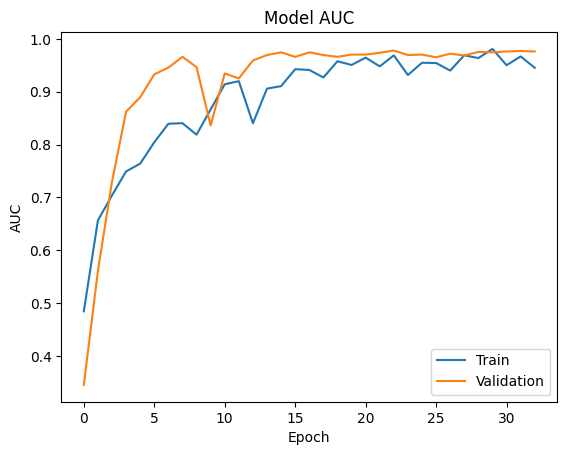

In [28]:
# =========================================================
# VISUALIZATION AUC
# =========================================================

plt.plot(history_stable_trial.history['auc'])
plt.plot(history_stable_trial.history['val_auc'])
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend(['Train', 'Validation'])
plt.show()

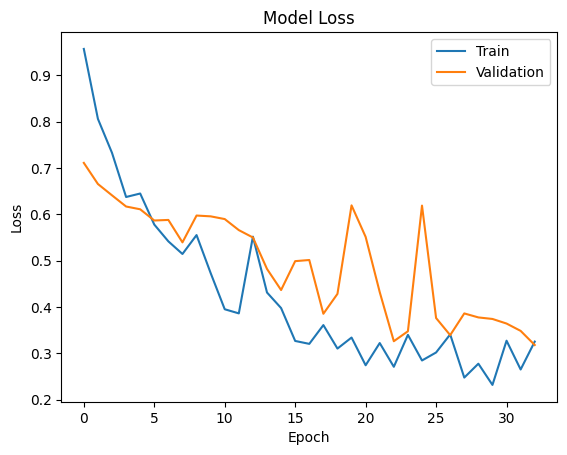

In [29]:
# =========================================================
# VISUALIZATION LOSS
# =========================================================

plt.plot(history_stable_trial.history['loss'])
plt.plot(history_stable_trial.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [30]:
# =========================================================
# TEST SAMPLE
# =========================================================

image_path = "sample-no.jpg"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model_stable_trial.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step

Prediction Probability:
[[0.37145704]]

Predicted Class:
no


In [31]:
image_path = "sample-yes.jpg"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model_stable_trial.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Prediction Probability:
[[0.8069957]]

Predicted Class:
yes
